# 09e — EGFR DiffDock Docking and Pose / Interaction Evaluation

## PEARL Pipeline 5

This notebook consumes the **09d docking shortlist** and prepares / analyses DiffDock docking
against EGFR chain B from PDB **3NJP**.

The finalized 09d production output contains 8 docking candidates, all explicitly labelled:

```text
docking_track = NEAR_MISS_RESCUE
pharmacophore_status = NEAR_MISS_MANDATORY_ONLY
chemistry_class = CHEM_PASS
```

The candidates are:

```text
MOL00053
MOL00484
MOL00273
MOL00600
MOL00294
MOL00857
MOL00583
MOL00489
```

### Methodological rule

A favorable DiffDock pose does **not** convert a near-miss rescue compound into a strict
pharmacophore hit. Provenance from 09d is preserved in every output table.

DiffDock confidence and contact metrics are used as **pose-ranking / structural plausibility
signals**, not as experimental binding affinity or free energy.


## 1. Two-stage execution

09e is deliberately split into two stages.

### Stage A — prepare DiffDock input
Runs in the normal PEARL environment and creates:

```text
09e_receptor_chain_B.pdb
09e_diffdock_input.csv
09e_run_diffdock.sh
```

### Stage B — analyse DiffDock outputs
After DiffDock has been run externally, rerun the notebook with:

```python
ANALYSE_EXISTING_DIFFDOCK_RESULTS = True
```

The notebook then reads all `rank*_confidence*.sdf` pose files, quantifies receptor contacts,
builds a pose-level ranking, selects the best pose per compound and exports the final 09e
shortlist.

This mirrors the external-tool handoff already used for REINVENT4.


In [1]:
from pathlib import Path
import json
import math
import re
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem

print("09e analysis environment loaded.")


09e analysis environment loaded.


## 2. Configuration


In [2]:
OUTPUTS_ROOT = Path("outputs")

# ======================================================
# Input from 09d
# ======================================================

INPUT_09D_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09d_chemical_filtering"
)

SHORTLIST_09D_PATH = (
    INPUT_09D_ROOT
    / "tables"
    / "09d_docking_shortlist.csv"
)

QC_09D_PATH = (
    INPUT_09D_ROOT
    / "tables"
    / "09d_QC.csv"
)

# ======================================================
# 09e output
# ======================================================

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09e_diffdock"
)

INPUT_DIR = OUTPUT_ROOT / "inputs"
DIFFDOCK_RESULT_DIR = OUTPUT_ROOT / "diffdock_results"
TABLE_DIR = OUTPUT_ROOT / "tables"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
PLOT_DIR = OUTPUT_ROOT / "plots"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    INPUT_DIR,
    DIFFDOCK_RESULT_DIR,
    TABLE_DIR,
    STRUCTURE_DIR,
    PLOT_DIR,
    REPORT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

# ======================================================
# Receptor
# ======================================================

PDB_ID = "3NJP"
RECEPTOR_CHAIN = "B"

# Search local paths first; download from RCSB only if absent.
PDB_CANDIDATES = [
    Path("3NJP.pdb"),
    Path("3njp.pdb"),
    Path("data") / "3NJP.pdb",
    Path("data") / "3njp.pdb",
    Path("inputs") / "3NJP.pdb",
    Path("outputs") / "3NJP.pdb",
]

FULL_PDB_PATH = INPUT_DIR / "3NJP.pdb"
RECEPTOR_PDB_PATH = INPUT_DIR / "09e_receptor_chain_B.pdb"

# ======================================================
# DiffDock
# ======================================================

DIFFDOCK_INPUT_CSV = INPUT_DIR / "09e_diffdock_input.csv"
DIFFDOCK_RUN_SCRIPT = INPUT_DIR / "09e_run_diffdock.sh"

# Change this only if your DiffDock clone is elsewhere.
DIFFDOCK_HOME = Path.home() / "Downloads" / "DiffDock"

DIFFDOCK_SAMPLES_PER_COMPLEX = 10
DIFFDOCK_INFERENCE_STEPS = 20
DIFFDOCK_BATCH_SIZE = 5

# Stage-B switch.
ANALYSE_EXISTING_DIFFDOCK_RESULTS = True

# ======================================================
# Contact analysis
# ======================================================

HEAVY_CONTACT_CUTOFF_A = 4.5
CLOSE_CONTACT_CUTOFF_A = 3.5
CLASH_CUTOFF_A = 2.0

TOP_POSES_PER_CANDIDATE = 10

print("09d shortlist:", SHORTLIST_09D_PATH)
print("09e output:", OUTPUT_ROOT)
print("Analyse existing results:", ANALYSE_EXISTING_DIFFDOCK_RESULTS)


09d shortlist: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/tables/09d_docking_shortlist.csv
09e output: outputs/pipeline_5_pharmacophore_09e_diffdock
Analyse existing results: True


## 3. Load and validate the 09d docking shortlist


In [3]:
required = [
    SHORTLIST_09D_PATH,
    QC_09D_PATH,
]

missing = [
    p for p in required
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required 09d outputs:\n"
        + "\n".join(
            str(p)
            for p in missing
        )
    )

shortlist = pd.read_csv(
    SHORTLIST_09D_PATH
)

qc09d = pd.read_csv(
    QC_09D_PATH
)

qc_flags = (
    qc09d["pass"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
    })
)

if qc_flags.isna().any():
    qc_flags = qc09d[
        "pass"
    ].astype(bool)

if not bool(
    qc_flags.all()
):
    raise RuntimeError(
        "09d QC did not pass completely."
    )

expected_cols = [
    "candidate_id",
    "canonical_smiles",
    "docking_track",
    "pharmacophore_status",
    "chemistry_class",
]

missing_cols = [
    col
    for col in expected_cols
    if col not in shortlist.columns
]

if missing_cols:
    raise KeyError(
        "Missing required 09d columns: "
        + ", ".join(
            missing_cols
        )
    )

print(
    "Docking candidates:",
    len(shortlist),
)

display(
    shortlist[
        [
            "09d_docking_rank",
            "candidate_id",
            "docking_track",
            "pharmacophore_status",
            "chemistry_class",
            "mandatory_rmsd_A",
            "chemistry_priority_score",
        ]
    ]
)


Docking candidates: 8


,09d_docking_rank,candidate_id,docking_track,pharmacophore_status,chemistry_class,mandatory_rmsd_A,chemistry_priority_score
0,1,MOL00053,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954
1,2,MOL00484,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.652652,4.341909
2,3,MOL00273,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.923718,3.926745
3,4,MOL00600,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.211674,3.902629
4,5,MOL00294,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.150579,3.842241
5,6,MOL00857,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.494548,3.814210
6,7,MOL00583,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.340579,3.781209
7,8,MOL00489,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.578156,3.755615


## 4. Acquire the 3NJP structure

The notebook first searches common local paths. If none exists, it downloads the PDB file
from the RCSB PDB archive.

No biological interpretation is inferred from this step; it only supplies the structural
coordinate file used previously in PEARL.


In [4]:
local_pdb = None

for candidate in PDB_CANDIDATES:
    if candidate.exists():
        local_pdb = candidate
        break

if local_pdb is not None:
    shutil.copy2(
        local_pdb,
        FULL_PDB_PATH,
    )

    print(
        "Using local PDB:",
        local_pdb,
    )

elif not FULL_PDB_PATH.exists():
    url = (
        f"https://files.rcsb.org/download/{PDB_ID}.pdb"
    )

    print(
        "Downloading:",
        url,
    )

    urllib.request.urlretrieve(
        url,
        FULL_PDB_PATH,
    )

print(
    "Full PDB:",
    FULL_PDB_PATH.resolve(),
)

if not FULL_PDB_PATH.exists():
    raise FileNotFoundError(
        "3NJP PDB file unavailable."
    )


Using local PDB: outputs/3NJP.pdb
Full PDB: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/inputs/3NJP.pdb


## 5. Extract receptor chain B

Only receptor chain **B** is written to the DiffDock receptor file.

Water and hetero-ligand records are excluded; standard `ATOM` records from chain B are retained.


In [5]:
input_lines = FULL_PDB_PATH.read_text(
    encoding="utf-8",
    errors="ignore",
).splitlines()

chain_lines = []

for line in input_lines:
    if not line.startswith(
        "ATOM"
    ):
        continue

    chain = (
        line[21].strip()
        if len(line) > 21
        else ""
    )

    if chain == RECEPTOR_CHAIN:
        chain_lines.append(
            line
        )

if not chain_lines:
    raise RuntimeError(
        f"No ATOM records found for chain {RECEPTOR_CHAIN}."
    )

RECEPTOR_PDB_PATH.write_text(
    "\n".join(
        chain_lines
        + ["TER", "END"]
    )
    + "\n",
    encoding="utf-8",
)

print(
    "Chain B ATOM records:",
    len(chain_lines),
)

print(
    "Receptor:",
    RECEPTOR_PDB_PATH.resolve(),
)


Chain B ATOM records: 4730
Receptor: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/inputs/09e_receptor_chain_B.pdb


## 6. Build the official DiffDock multi-complex CSV

Current DiffDock accepts a multi-complex CSV with:

```text
complex_name
protein_path
protein_sequence
ligand_description
```

`ligand_description` may be a SMILES string.

The receptor path is written as an **absolute path** so that the CSV can be read while DiffDock
is launched from its own repository directory.


In [6]:
diffdock_input = pd.DataFrame({
    "complex_name": shortlist[
        "candidate_id"
    ].astype(str),
    "protein_path": str(
        RECEPTOR_PDB_PATH.resolve()
    ),
    "protein_sequence": "",
    "ligand_description": shortlist[
        "canonical_smiles"
    ].astype(str),
})

diffdock_input.to_csv(
    DIFFDOCK_INPUT_CSV,
    index=False,
)

print(
    "DiffDock complexes:",
    len(diffdock_input),
)

print(
    "CSV:",
    DIFFDOCK_INPUT_CSV.resolve(),
)

display(
    diffdock_input
)


DiffDock complexes: 8
CSV: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/inputs/09e_diffdock_input.csv


,complex_name,protein_path,protein_sequence,ligand_description
0,MOL00053,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
1,MOL00484,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,Cn1nc(C(=O)N2CCCC(CC(N)=O)C2)cc1-c1ccc(Cl)cc1
2,MOL00273,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,O=C(O)CSCC(=O)Nc1nc(-c2cc3ccccc3o2)cs1
3,MOL00600,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,CC(=O)Nc1cc(N2CN(C3CCC(C4CCN(C(C)=O)CC4)CC3)C(...
4,MOL00294,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,O=C(CCc1nc(-c2cccs2)no1)Nc1cccc(N2CCN(C(=O)C3C...
5,MOL00857,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,COc1cc(-c2ccnc(C3CCCCN3C(=O)c3ncc(C(=O)O)cn3)n...
6,MOL00583,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,COc1ccc(NC(C)=O)cc1NC(=O)c1cnc(Nc2ccc(C)c(C)c2...
7,MOL00489,/Users/robertobruzzese/Desktop/venv/outputs/pi...,,CC1(C)NCCc2cc(C(=O)Nc3ccc(-c4ccc(N)nc4)cn3)c(C...


## 7. Generate the external DiffDock command

Run this script in a **separate DiffDock environment**.

The notebook does not install DiffDock into `pearl-md`.

The current official inference entry point supports `--protein_ligand_csv`,
`--samples_per_complex`, `--batch_size`, `--inference_steps` and `--out_dir`.


In [7]:
command = (
    f'cd "{DIFFDOCK_HOME}"\n'
    f'python -m inference '
    f'--config default_inference_args.yaml '
    f'--protein_ligand_csv "{DIFFDOCK_INPUT_CSV.resolve()}" '
    f'--out_dir "{DIFFDOCK_RESULT_DIR.resolve()}" '
    f'--samples_per_complex {DIFFDOCK_SAMPLES_PER_COMPLEX} '
    f'--inference_steps {DIFFDOCK_INFERENCE_STEPS} '
    f'--batch_size {DIFFDOCK_BATCH_SIZE}\n'
)

script_text = (
    "#!/bin/bash\n"
    "set -e\n"
    + command
)

DIFFDOCK_RUN_SCRIPT.write_text(
    script_text,
    encoding="utf-8",
)

DIFFDOCK_RUN_SCRIPT.chmod(
    0o755
)

print(
    "Run script:",
    DIFFDOCK_RUN_SCRIPT.resolve(),
)

print()
print(
    script_text
)


Run script: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/inputs/09e_run_diffdock.sh

#!/bin/bash
set -e
cd "/Users/robertobruzzese/Downloads/DiffDock"
python -m inference --config default_inference_args.yaml --protein_ligand_csv "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/inputs/09e_diffdock_input.csv" --out_dir "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09e_diffdock/diffdock_results" --samples_per_complex 10 --inference_steps 20 --batch_size 5



## 8. Stage-A status

At this point the notebook has completed input preparation.

If DiffDock has **not** yet been run, stop here and execute the generated shell script from a
terminal in the DiffDock environment.

After DiffDock finishes, set:

```python
ANALYSE_EXISTING_DIFFDOCK_RESULTS = True
```

and rerun the notebook.


In [8]:
expected_candidate_dirs = [
    DIFFDOCK_RESULT_DIR
    / str(candidate_id)
    for candidate_id in shortlist[
        "candidate_id"
    ]
]

n_candidate_dirs = sum(
    p.exists()
    for p in expected_candidate_dirs
)

print(
    "DiffDock result directories currently present:",
    n_candidate_dirs,
    "/",
    len(expected_candidate_dirs),
)

if not ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    print(
        "\nSTAGE A COMPLETE."
    )
    print(
        "Run DiffDock externally, then set "
        "ANALYSE_EXISTING_DIFFDOCK_RESULTS = True."
    )


DiffDock result directories currently present: 8 / 8


# Stage B — DiffDock output analysis


## 9. Parse receptor atoms

Heavy-atom coordinates, residue identifiers and element names are extracted directly from the
chain-B PDB file.

The structural metrics below are deliberately simple and transparent:

- heavy-atom contacts ≤ 4.5 Å;
- close contacts ≤ 3.5 Å;
- severe clashes < 2.0 Å;
- unique contacted receptor residues.

These are descriptive pose-contact metrics, not an interaction-energy model.


In [9]:
def parse_receptor_atoms(pdb_path):
    rows = []

    for line in Path(
        pdb_path
    ).read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines():

        if not line.startswith(
            "ATOM"
        ):
            continue

        atom_name = line[
            12:16
        ].strip()

        resname = line[
            17:20
        ].strip()

        chain = (
            line[21].strip()
            if len(line) > 21
            else ""
        )

        resseq = line[
            22:26
        ].strip()

        icode = (
            line[26].strip()
            if len(line) > 26
            else ""
        )

        x = float(
            line[30:38]
        )
        y = float(
            line[38:46]
        )
        z = float(
            line[46:54]
        )

        element = (
            line[76:78].strip()
            if len(line) >= 78
            else ""
        )

        if not element:
            element = re.sub(
                r"[^A-Za-z]",
                "",
                atom_name,
            )[:1].upper()

        if element.upper() == "H":
            continue

        residue_id = (
            f"{chain}:{resname}{resseq}{icode}"
        )

        rows.append({
            "atom_name": atom_name,
            "resname": resname,
            "chain": chain,
            "resseq": resseq,
            "residue_id": residue_id,
            "element": element.upper(),
            "x": x,
            "y": y,
            "z": z,
        })

    return pd.DataFrame(
        rows
    )

receptor_atoms = parse_receptor_atoms(
    RECEPTOR_PDB_PATH
)

if receptor_atoms.empty:
    raise RuntimeError(
        "No receptor atoms parsed."
    )

RECEPTOR_XYZ = receptor_atoms[
    ["x", "y", "z"]
].to_numpy(
    dtype=float
)

print(
    "Receptor heavy atoms:",
    len(receptor_atoms),
)


Receptor heavy atoms: 4730


## 10. Discover DiffDock pose files


In [10]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    missing_result_dirs = [
        p
        for p in expected_candidate_dirs
        if not p.exists()
    ]

    if missing_result_dirs:
        warnings.warn(
            "Missing DiffDock result directories:\n"
            + "\n".join(
                str(p)
                for p in missing_result_dirs
            )
        )

def pose_rank_from_name(name):
    match = re.search(
        r"rank(\d+)",
        name,
    )

    if match:
        return int(
            match.group(1)
        )

    return None

def confidence_from_name(name):
    match = re.search(
        r"confidence(-?\d+(?:\.\d+)?)",
        name,
    )

    if match:
        return float(
            match.group(1)
        )

    return np.nan

pose_files = []

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    for candidate_id in shortlist[
        "candidate_id"
    ].astype(str):

        candidate_dir = (
            DIFFDOCK_RESULT_DIR
            / candidate_id
        )

        if not candidate_dir.exists():
            continue

        files = sorted(
            candidate_dir.glob(
                "rank*_confidence*.sdf"
            ),
            key=lambda p: (
                pose_rank_from_name(
                    p.name
                )
                or 999
            ),
        )

        # Fall back to rank1.sdf only if confidence files are absent.
        if not files:
            files = sorted(
                candidate_dir.glob(
                    "rank*.sdf"
                )
            )

        for path in files[
            :TOP_POSES_PER_CANDIDATE
        ]:
            pose_files.append({
                "candidate_id": candidate_id,
                "pose_rank": pose_rank_from_name(
                    path.name
                ),
                "diffdock_confidence": confidence_from_name(
                    path.name
                ),
                "pose_path": str(
                    path
                ),
            })

pose_index_df = pd.DataFrame(
    pose_files
)

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    print(
        "Pose files discovered:",
        len(pose_index_df),
    )

    display(
        pose_index_df.head(
            25
        )
    )


Pose files discovered: 80


,candidate_id,pose_rank,diffdock_confidence,pose_path
0,MOL00053,1,-2.19,outputs/pipeline_5_pharmacophore_09e_diffdock/...
1,MOL00053,2,-2.63,outputs/pipeline_5_pharmacophore_09e_diffdock/...
2,MOL00053,3,-2.73,outputs/pipeline_5_pharmacophore_09e_diffdock/...
3,MOL00053,4,-3.11,outputs/pipeline_5_pharmacophore_09e_diffdock/...
4,MOL00053,5,-3.20,outputs/pipeline_5_pharmacophore_09e_diffdock/...
5,MOL00053,6,-3.54,outputs/pipeline_5_pharmacophore_09e_diffdock/...
6,MOL00053,7,-3.58,outputs/pipeline_5_pharmacophore_09e_diffdock/...
7,MOL00053,8,-4.04,outputs/pipeline_5_pharmacophore_09e_diffdock/...
8,MOL00053,9,-5.36,outputs/pipeline_5_pharmacophore_09e_diffdock/...
9,MOL00053,10,-5.98,outputs/pipeline_5_pharmacophore_09e_diffdock/...


## 11. Quantify receptor–ligand contacts for each pose


In [11]:
def ligand_heavy_xyz_from_sdf(
    sdf_path
):
    supplier = Chem.SDMolSupplier(
        str(sdf_path),
        removeHs=False,
        sanitize=True,
    )

    mol = next(
        (
            m
            for m in supplier
            if m is not None
        ),
        None,
    )

    if mol is None:
        return None, None

    conf = mol.GetConformer()

    coords = []
    elements = []

    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 1:
            continue

        pos = conf.GetAtomPosition(
            atom.GetIdx()
        )

        coords.append(
            [
                float(pos.x),
                float(pos.y),
                float(pos.z),
            ]
        )

        elements.append(
            atom.GetSymbol().upper()
        )

    return (
        np.asarray(
            coords,
            dtype=float,
        ),
        elements,
    )

def evaluate_pose(
    sdf_path
):
    ligand_xyz, ligand_elements = (
        ligand_heavy_xyz_from_sdf(
            sdf_path
        )
    )

    if ligand_xyz is None:
        return None

    # Shape:
    # ligand atoms x receptor atoms
    diff = (
        ligand_xyz[
            :,
            None,
            :
        ]
        - RECEPTOR_XYZ[
            None,
            :,
            :
        ]
    )

    dist = np.linalg.norm(
        diff,
        axis=2,
    )

    min_distance = float(
        dist.min()
    )

    contact_mask = (
        dist
        <= HEAVY_CONTACT_CUTOFF_A
    )

    close_mask = (
        dist
        <= CLOSE_CONTACT_CUTOFF_A
    )

    clash_mask = (
        dist
        < CLASH_CUTOFF_A
    )

    contact_pairs = int(
        contact_mask.sum()
    )

    close_pairs = int(
        close_mask.sum()
    )

    clash_pairs = int(
        clash_mask.sum()
    )

    receptor_contact_atom_indices = np.where(
        contact_mask.any(
            axis=0
        )
    )[0]

    contacted_residues = sorted(
        set(
            receptor_atoms.iloc[
                receptor_contact_atom_indices
            ][
                "residue_id"
            ].astype(str)
        )
    )

    ligand_contact_atoms = int(
        contact_mask.any(
            axis=1
        ).sum()
    )

    ligand_contact_fraction = (
        ligand_contact_atoms
        / max(
            1,
            ligand_xyz.shape[0],
        )
    )

    return {
        "ligand_heavy_atoms": int(
            ligand_xyz.shape[0]
        ),
        "min_receptor_distance_A": min_distance,
        "heavy_contact_pairs_4p5A": contact_pairs,
        "close_contact_pairs_3p5A": close_pairs,
        "clash_pairs_lt2A": clash_pairs,
        "contacted_receptor_residues": len(
            contacted_residues
        ),
        "contact_residue_ids": ";".join(
            contacted_residues
        ),
        "ligand_contact_atoms": ligand_contact_atoms,
        "ligand_contact_fraction": float(
            ligand_contact_fraction
        ),
    }

pose_metric_rows = []

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    for row in pose_index_df.itertuples():
        metrics = evaluate_pose(
            row.pose_path
        )

        if metrics is None:
            continue

        pose_metric_rows.append({
            "candidate_id": row.candidate_id,
            "pose_rank": row.pose_rank,
            "diffdock_confidence": row.diffdock_confidence,
            "pose_path": row.pose_path,
            **metrics,
        })

pose_metrics_df = pd.DataFrame(
    pose_metric_rows
)

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    print(
        "Poses successfully analysed:",
        len(pose_metrics_df),
    )

    display(
        pose_metrics_df.head(
            25
        )
    )


Poses successfully analysed: 80


,candidate_id,pose_rank,diffdock_confidence,pose_path,ligand_heavy_atoms,min_receptor_distance_A,heavy_contact_pairs_4p5A,close_contact_pairs_3p5A,clash_pairs_lt2A,contacted_receptor_residues,contact_residue_ids,ligand_contact_atoms,ligand_contact_fraction
0,MOL00053,1,-2.19,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,0.737271,112,39,5,11,B:ARG405;B:ASN274;B:ASP434;B:GLY404;B:GLY410;B...,19,0.826087
1,MOL00053,2,-2.63,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.636366,50,16,1,6,B:ARG231;B:GLU233;B:GLU3;B:LYS269;B:PHE263;B:V...,19,0.826087
2,MOL00053,3,-2.73,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.768003,69,13,0,9,B:ALA265;B:ARG285;B:CYS283;B:GLY264;B:PHE230;B...,15,0.652174
3,MOL00053,4,-3.11,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.086222,92,30,0,5,B:ALA542;B:ASN544;B:GLN541;B:GLN557;B:MET543,23,1.000000
4,MOL00053,5,-3.20,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.820238,30,7,0,4,B:ARG231;B:GLU2;B:GLU3;B:LEU1,10,0.434783
5,MOL00053,6,-3.54,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.338635,71,33,2,4,B:GLU233;B:GLU3;B:PHE263;B:VAL268,20,0.869565
6,MOL00053,7,-3.58,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.533801,95,33,2,6,B:ARG231;B:GLN59;B:GLU233;B:LEU1;B:LEU225;B:LYS4,22,0.956522
7,MOL00053,8,-4.04,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,0.960681,138,45,5,13,B:ARG285;B:ARG405;B:ASN274;B:ASP434;B:GLN8;B:G...,22,0.956522
8,MOL00053,9,-5.36,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.041764,157,65,6,8,B:ARG114;B:ASN115;B:ASN79;B:GLU180;B:GLU181;B:...,23,1.000000
9,MOL00053,10,-5.98,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,64.715580,0,0,0,0,,0,0.000000


## 12. Merge 09d provenance into every pose

The provenance columns are copied unchanged from 09d.


In [12]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    provenance_cols = [
        "candidate_id",
        "09d_docking_rank",
        "docking_track",
        "pharmacophore_status",
        "chemistry_class",
        "mandatory_rmsd_A",
        "chemistry_priority_score",
        "canonical_smiles",
    ]

    pose_df = pose_metrics_df.merge(
        shortlist[
            provenance_cols
        ],
        on="candidate_id",
        how="left",
    )

    pose_df.to_csv(
        TABLE_DIR
        / "09e_all_diffdock_poses_with_contacts.csv",
        index=False,
    )

    display(
        pose_df.head(
            25
        )
    )


,candidate_id,pose_rank,diffdock_confidence,pose_path,ligand_heavy_atoms,min_receptor_distance_A,heavy_contact_pairs_4p5A,close_contact_pairs_3p5A,clash_pairs_lt2A,contacted_receptor_residues,contact_residue_ids,ligand_contact_atoms,ligand_contact_fraction,09d_docking_rank,docking_track,pharmacophore_status,chemistry_class,mandatory_rmsd_A,chemistry_priority_score,canonical_smiles
0,MOL00053,1,-2.19,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,0.737271,112,39,5,11,B:ARG405;B:ASN274;B:ASP434;B:GLY404;B:GLY410;B...,19,0.826087,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
1,MOL00053,2,-2.63,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.636366,50,16,1,6,B:ARG231;B:GLU233;B:GLU3;B:LYS269;B:PHE263;B:V...,19,0.826087,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
2,MOL00053,3,-2.73,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.768003,69,13,0,9,B:ALA265;B:ARG285;B:CYS283;B:GLY264;B:PHE230;B...,15,0.652174,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
3,MOL00053,4,-3.11,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.086222,92,30,0,5,B:ALA542;B:ASN544;B:GLN541;B:GLN557;B:MET543,23,1.000000,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
4,MOL00053,5,-3.20,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,2.820238,30,7,0,4,B:ARG231;B:GLU2;B:GLU3;B:LEU1,10,0.434783,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
5,MOL00053,6,-3.54,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.338635,71,33,2,4,B:GLU233;B:GLU3;B:PHE263;B:VAL268,20,0.869565,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
6,MOL00053,7,-3.58,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.533801,95,33,2,6,B:ARG231;B:GLN59;B:GLU233;B:LEU1;B:LEU225;B:LYS4,22,0.956522,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
7,MOL00053,8,-4.04,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,0.960681,138,45,5,13,B:ARG285;B:ARG405;B:ASN274;B:ASP434;B:GLN8;B:G...,22,0.956522,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
8,MOL00053,9,-5.36,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,1.041764,157,65,6,8,B:ARG114;B:ASN115;B:ASN79;B:GLU180;B:GLU181;B:...,23,1.000000,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1
9,MOL00053,10,-5.98,outputs/pipeline_5_pharmacophore_09e_diffdock/...,23,64.715580,0,0,0,0,,0,0.000000,1,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1.356111,4.365954,Cc1cc(NC(=O)N2CC(OCCO)C2)n(-c2ccccc2)n1


## 13. Pose plausibility flags

A pose is marked:

```text
severe_clash = at least one receptor–ligand heavy-atom pair < 2.0 Å
interface_contact = at least one heavy-atom contact <= 4.5 Å
```

These flags are intentionally simple and auditable.


In [13]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    pose_df[
        "severe_clash"
    ] = (
        pose_df[
            "clash_pairs_lt2A"
        ]
        > 0
    )

    pose_df[
        "interface_contact"
    ] = (
        pose_df[
            "heavy_contact_pairs_4p5A"
        ]
        > 0
    )

    pose_df[
        "pose_structurally_usable"
    ] = (
        pose_df[
            "interface_contact"
        ]
        & ~pose_df[
            "severe_clash"
        ]
    )

    display(
        pose_df[
            [
                "candidate_id",
                "pose_rank",
                "diffdock_confidence",
                "min_receptor_distance_A",
                "heavy_contact_pairs_4p5A",
                "contacted_receptor_residues",
                "ligand_contact_fraction",
                "clash_pairs_lt2A",
                "pose_structurally_usable",
            ]
        ].head(
            30
        )
    )


,candidate_id,pose_rank,diffdock_confidence,min_receptor_distance_A,heavy_contact_pairs_4p5A,contacted_receptor_residues,ligand_contact_fraction,clash_pairs_lt2A,pose_structurally_usable
0,MOL00053,1,-2.19,0.737271,112,11,0.826087,5,False
1,MOL00053,2,-2.63,1.636366,50,6,0.826087,1,False
2,MOL00053,3,-2.73,2.768003,69,9,0.652174,0,True
3,MOL00053,4,-3.11,2.086222,92,5,1.000000,0,True
4,MOL00053,5,-3.20,2.820238,30,4,0.434783,0,True
5,MOL00053,6,-3.54,1.338635,71,4,0.869565,2,False
6,MOL00053,7,-3.58,1.533801,95,6,0.956522,2,False
7,MOL00053,8,-4.04,0.960681,138,13,0.956522,5,False
8,MOL00053,9,-5.36,1.041764,157,8,1.000000,6,False
9,MOL00053,10,-5.98,64.715580,0,0,0.000000,0,False


## 14. Descriptive integrated pose score

The integrated score ranks **poses**, not biological activity.

It combines:

- normalized DiffDock confidence within the current experiment;
- fraction of ligand heavy atoms contacting receptor;
- number of contacted receptor residues;
- severe clash penalty.

No 09d near-miss is relabelled as a strict pharmacophore hit.


In [14]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    confidence = pose_df[
        "diffdock_confidence"
    ].astype(float)

    if confidence.notna().sum() > 1:
        cmin = float(
            confidence.min()
        )
        cmax = float(
            confidence.max()
        )

        if cmax > cmin:
            conf_norm = (
                confidence - cmin
            ) / (
                cmax - cmin
            )
        else:
            conf_norm = pd.Series(
                0.5,
                index=pose_df.index,
            )
    else:
        conf_norm = pd.Series(
            0.5,
            index=pose_df.index,
        )

    residue_norm = np.clip(
        pose_df[
            "contacted_receptor_residues"
        ].astype(float)
        / 15.0,
        0.0,
        1.0,
    )

    pose_df[
        "diffdock_confidence_norm"
    ] = conf_norm.fillna(
        0.0
    )

    pose_df[
        "pose_support_score"
    ] = (
        0.55
        * pose_df[
            "diffdock_confidence_norm"
        ]
        + 0.25
        * pose_df[
            "ligand_contact_fraction"
        ].astype(float)
        + 0.20
        * residue_norm
        - 1.00
        * pose_df[
            "severe_clash"
        ].astype(float)
    )

    pose_df = pose_df.sort_values(
        [
            "pose_structurally_usable",
            "pose_support_score",
            "diffdock_confidence",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )

    pose_df.to_csv(
        TABLE_DIR
        / "09e_pose_ranking.csv",
        index=False,
    )

    display(
        pose_df[
            [
                "candidate_id",
                "pose_rank",
                "diffdock_confidence",
                "pose_support_score",
                "contacted_receptor_residues",
                "ligand_contact_fraction",
                "severe_clash",
            ]
        ].head(
            30
        )
    )


,candidate_id,pose_rank,diffdock_confidence,pose_support_score,contacted_receptor_residues,ligand_contact_fraction,severe_clash
0,MOL00273,1,-0.88,0.849855,7,0.826087,False
1,MOL00583,1,-2.02,0.827007,12,0.933333,False
2,MOL00600,4,-1.89,0.794880,9,0.911765,False
3,MOL00273,2,-2.31,0.776545,10,0.956522,False
4,MOL00484,4,-3.00,0.770340,14,1.000000,False
5,MOL00600,2,-1.82,0.722513,8,0.647059,False
6,MOL00484,3,-2.61,0.693469,6,0.960000,False
7,MOL00857,3,-2.97,0.692047,12,0.781250,False
8,MOL00600,1,-1.74,0.674598,6,0.529412,False
9,MOL00273,4,-2.56,0.673499,5,0.913043,False


## 15. Select the best pose for each compound

The best structurally usable pose is selected first; if none is usable, the highest-ranked
available pose is retained and flagged.


In [15]:
best_pose_rows = []

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    for candidate_id, group in pose_df.groupby(
        "candidate_id",
        sort=False,
    ):
        usable = group[
            group[
                "pose_structurally_usable"
            ]
        ]

        source = (
            usable
            if len(usable)
            else group
        )

        best = source.sort_values(
            [
                "pose_support_score",
                "diffdock_confidence",
            ],
            ascending=[
                False,
                False,
            ],
        ).iloc[0]

        best_pose_rows.append(
            best.to_dict()
        )

best_pose_df = pd.DataFrame(
    best_pose_rows
)

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    best_pose_df = best_pose_df.sort_values(
        [
            "pose_structurally_usable",
            "pose_support_score",
        ],
        ascending=[
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )

    best_pose_df.insert(
        0,
        "09e_candidate_rank",
        np.arange(
            1,
            len(best_pose_df) + 1,
        ),
    )

    best_pose_df.to_csv(
        TABLE_DIR
        / "09e_best_pose_per_candidate.csv",
        index=False,
    )

    display(
        best_pose_df[
            [
                "09e_candidate_rank",
                "candidate_id",
                "docking_track",
                "pharmacophore_status",
                "chemistry_class",
                "pose_rank",
                "diffdock_confidence",
                "pose_support_score",
                "contacted_receptor_residues",
                "ligand_contact_fraction",
                "severe_clash",
            ]
        ]
    )


,09e_candidate_rank,candidate_id,docking_track,pharmacophore_status,chemistry_class,pose_rank,diffdock_confidence,pose_support_score,contacted_receptor_residues,ligand_contact_fraction,severe_clash
0,1,MOL00273,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1,-0.88,0.849855,7,0.826087,False
1,2,MOL00583,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1,-2.02,0.827007,12,0.933333,False
2,3,MOL00600,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4,-1.89,0.794880,9,0.911765,False
3,4,MOL00484,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4,-3.00,0.770340,14,1.000000,False
4,5,MOL00857,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.97,0.692047,12,0.781250,False
5,6,MOL00053,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.73,0.644268,9,0.652174,False
6,7,MOL00489,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.33,0.641926,7,0.586207,False
7,8,MOL00294,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,10,-5.97,0.030612,0,0.000000,False


## 16. Copy the selected pose structures

The selected pose SDF files are copied into a stable 09e structures directory.


In [16]:
copy_rows = []

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    for row in best_pose_df.itertuples():
        src = Path(
            row.pose_path
        )

        dst = (
            STRUCTURE_DIR
            / (
                f"{row.candidate_id}"
                f"_selected_rank{int(row.pose_rank)}.sdf"
            )
        )

        if src.exists():
            shutil.copy2(
                src,
                dst,
            )

            copied = True
        else:
            copied = False

        copy_rows.append({
            "candidate_id": row.candidate_id,
            "source_pose": str(src),
            "selected_pose": str(dst),
            "copied": copied,
        })

selected_structure_df = pd.DataFrame(
    copy_rows
)

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    selected_structure_df.to_csv(
        TABLE_DIR
        / "09e_selected_pose_files.csv",
        index=False,
    )

    print(
        "Selected pose structures copied:",
        int(
            selected_structure_df[
                "copied"
            ].sum()
        ),
        "/",
        len(selected_structure_df),
    )


Selected pose structures copied: 8 / 8


## 17. Candidate-level docking plots


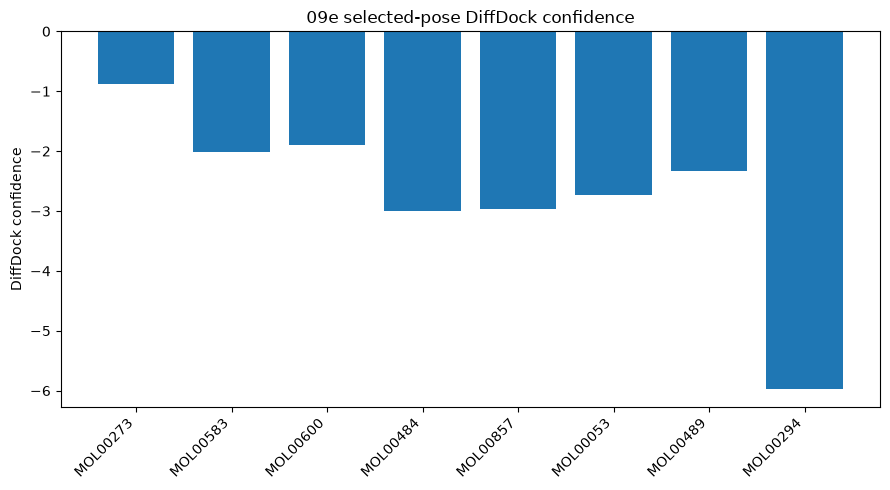

Saved: outputs/pipeline_5_pharmacophore_09e_diffdock/plots/09e_selected_pose_confidence.png


In [17]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS and len(
    best_pose_df
):
    plt.figure(
        figsize=(9, 5)
    )

    x = np.arange(
        len(
            best_pose_df
        )
    )

    plt.bar(
        x,
        best_pose_df[
            "diffdock_confidence"
        ],
    )

    plt.xticks(
        x,
        best_pose_df[
            "candidate_id"
        ],
        rotation=45,
        ha="right",
    )

    plt.ylabel(
        "DiffDock confidence"
    )

    plt.title(
        "09e selected-pose DiffDock confidence"
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09e_selected_pose_confidence.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


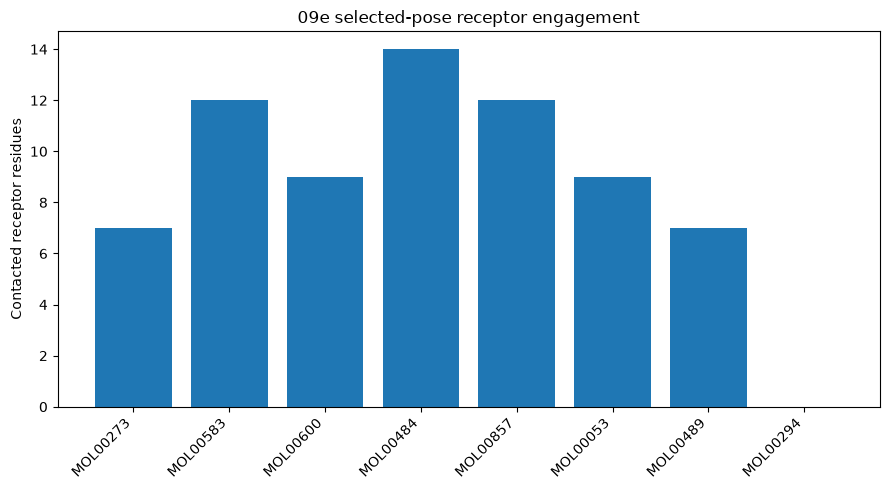

Saved: outputs/pipeline_5_pharmacophore_09e_diffdock/plots/09e_selected_pose_contact_residues.png


In [18]:
if ANALYSE_EXISTING_DIFFDOCK_RESULTS and len(
    best_pose_df
):
    plt.figure(
        figsize=(9, 5)
    )

    x = np.arange(
        len(
            best_pose_df
        )
    )

    plt.bar(
        x,
        best_pose_df[
            "contacted_receptor_residues"
        ],
    )

    plt.xticks(
        x,
        best_pose_df[
            "candidate_id"
        ],
        rotation=45,
        ha="right",
    )

    plt.ylabel(
        "Contacted receptor residues"
    )

    plt.title(
        "09e selected-pose receptor engagement"
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09e_selected_pose_contact_residues.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


## 18. QC

Technical QC checks:

- 09d QC passed;
- all 09d candidates preserved in the DiffDock input CSV;
- receptor chain B prepared;
- when Stage B is active, at least one pose is found for each candidate;
- provenance labels are unchanged;
- selected-pose files are exported.

A poor docking result is scientifically valid and must not be hidden.


In [19]:
qc_rows = [
    {
        "check": "09d_QC_passed",
        "pass": bool(
            qc_flags.all()
        ),
    },
    {
        "check": "receptor_chain_B_created",
        "pass": RECEPTOR_PDB_PATH.exists(),
    },
    {
        "check": "diffdock_input_contains_all_09d_candidates",
        "pass": (
            set(
                diffdock_input[
                    "complex_name"
                ].astype(str)
            )
            == set(
                shortlist[
                    "candidate_id"
                ].astype(str)
            )
        ),
    },
    {
        "check": "diffdock_input_csv_created",
        "pass": DIFFDOCK_INPUT_CSV.exists(),
    },
    {
        "check": "diffdock_run_script_created",
        "pass": DIFFDOCK_RUN_SCRIPT.exists(),
    },
]

if ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    pose_candidate_ids = set(
        pose_df[
            "candidate_id"
        ].astype(str)
    )

    input_candidate_ids = set(
        shortlist[
            "candidate_id"
        ].astype(str)
    )

    provenance_ok = True

    for col in [
        "docking_track",
        "pharmacophore_status",
        "chemistry_class",
    ]:
        merged = best_pose_df[
            [
                "candidate_id",
                col,
            ]
        ].merge(
            shortlist[
                [
                    "candidate_id",
                    col,
                ]
            ],
            on="candidate_id",
            suffixes=(
                "_09e",
                "_09d",
            ),
        )

        provenance_ok = (
            provenance_ok
            and bool(
                (
                    merged[
                        f"{col}_09e"
                    ].astype(str)
                    == merged[
                        f"{col}_09d"
                    ].astype(str)
                ).all()
            )
        )

    qc_rows.extend([
        {
            "check": "at_least_one_pose_per_candidate",
            "pass": (
                pose_candidate_ids
                == input_candidate_ids
            ),
        },
        {
            "check": "best_pose_per_candidate_created",
            "pass": (
                len(
                    best_pose_df
                )
                == len(
                    shortlist
                )
            ),
        },
        {
            "check": "09d_provenance_preserved",
            "pass": provenance_ok,
        },
        {
            "check": "selected_pose_structures_exported",
            "pass": (
                len(
                    selected_structure_df
                )
                > 0
                and bool(
                    selected_structure_df[
                        "copied"
                    ].all()
                )
            ),
        },
    ])

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09e_QC.csv",
    index=False,
)


,check,pass
0,09d_QC_passed,True
1,receptor_chain_B_created,True
2,diffdock_input_contains_all_09d_candidates,True
3,diffdock_input_csv_created,True
4,diffdock_run_script_created,True
5,at_least_one_pose_per_candidate,True
6,best_pose_per_candidate_created,True
7,09d_provenance_preserved,True
8,selected_pose_structures_exported,True


ALL QC PASSED: True


## 19. Automatic report


In [20]:
report_lines = [
    "# 09e — EGFR DiffDock Docking and Pose / Interaction Evaluation",
    "",
    "## Input",
    f"- 09d docking candidates: {len(shortlist)}",
    f"- Receptor: PDB {PDB_ID}, chain {RECEPTOR_CHAIN}",
    f"- DiffDock samples per complex requested: {DIFFDOCK_SAMPLES_PER_COMPLEX}",
    f"- DiffDock inference steps requested: {DIFFDOCK_INFERENCE_STEPS}",
    "",
]

if not ANALYSE_EXISTING_DIFFDOCK_RESULTS:
    report_lines.extend([
        "## Status",
        "- Stage A complete: DiffDock input and run script prepared.",
        "- Stage B not yet executed.",
        "",
        f"- DiffDock CSV: {DIFFDOCK_INPUT_CSV.resolve()}",
        f"- DiffDock script: {DIFFDOCK_RUN_SCRIPT.resolve()}",
    ])

else:
    report_lines.extend([
        "## Docking output",
        f"- Pose files analysed: {len(pose_df)}",
        f"- Candidates with a selected best pose: {len(best_pose_df)}",
        "",
        "## Best pose per candidate",
    ])

    for row in best_pose_df.itertuples():
        report_lines.append(
            (
                f"- {row.candidate_id} | 09e rank={int(row._1)} | "
                f"DiffDock rank={int(row.pose_rank)} | "
                f"confidence={row.diffdock_confidence:.3f} | "
                f"pose support={row.pose_support_score:.3f} | "
                f"contact residues={int(row.contacted_receptor_residues)} | "
                f"ligand contact fraction={row.ligand_contact_fraction:.3f} | "
                f"severe clash={bool(row.severe_clash)} | "
                f"track={row.docking_track}"
            )
        )

    report_lines.extend([
        "",
        "## Interpretation",
        (
            "DiffDock confidence is a model-derived pose-confidence signal and is not "
            "interpreted as binding free energy."
        ),
        (
            "Contact counts are descriptive geometric metrics based on heavy-atom "
            "distance cutoffs."
        ),
        (
            "All current 09d docking candidates are near-miss rescue compounds; "
            "favorable docking does not convert them into strict pharmacophore hits."
        ),
    ])

report_lines.extend([
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09e_diffdock_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09e — EGFR DiffDock Docking and Pose / Interaction Evaluation

## Input
- 09d docking candidates: 8
- Receptor: PDB 3NJP, chain B
- DiffDock samples per complex requested: 10
- DiffDock inference steps requested: 20

## Docking output
- Pose files analysed: 80
- Candidates with a selected best pose: 8

## Best pose per candidate
- MOL00273 | 09e rank=1 | DiffDock rank=1 | confidence=-0.880 | pose support=0.850 | contact residues=7 | ligand contact fraction=0.826 | severe clash=False | track=NEAR_MISS_RESCUE
- MOL00583 | 09e rank=2 | DiffDock rank=1 | confidence=-2.020 | pose support=0.827 | contact residues=12 | ligand contact fraction=0.933 | severe clash=False | track=NEAR_MISS_RESCUE
- MOL00600 | 09e rank=3 | DiffDock rank=4 | confidence=-1.890 | pose support=0.795 | contact residues=9 | ligand contact fraction=0.912 | severe clash=False | track=NEAR_MISS_RESCUE
- MOL00484 | 09e rank=4 | DiffDock rank=4 | confidence=-3.000 | pose support=0.770 | contact residues=14 | ligand contac

# 20. Interpretation and next step

When Stage B finishes with `ALL QC PASSED: True`, 09e is complete.

The output is a receptor-bound structural hypothesis for each chemically prioritized rescue
compound.

The next stage should compare the selected docking poses by:

```text
DiffDock confidence
+
interface contacts
+
pharmacophore provenance
+
09d chemistry
```

without forcing these heterogeneous signals into an unsupported binding-affinity claim.

A natural next notebook is:

```text
09f — Docking interaction refinement / energetic ranking
```

where selected poses can undergo more chemistry-aware interaction analysis and, if the chosen
protocol supports it, an MM-GBSA-style comparative energetic layer.
